# Sensitivity Analysis: Stem+Leaf Storage Hydraulics

This notebook runs multiple simulations using `HalophyteStemLeafStorageMultiComp` (hydraulics) and `C3_cs_reduc` (photosynthesis).

The initial setup includes 3 scenarios with varied:
- `pi0_stem`
- `pi0_leaf`
- `VWT` (stem storage volume)
- `GWMAX` mode (`manual` or `equation`)

`GWMAX` equation option uses the same form as in the `Pecan` species class:

`GWMAX = CAP * VWT * 10**6 / (0.63 * 4 * 60 * 60)`

In [1]:
%load_ext autoreload
%autoreload 2
%aimport hydraulics
%aimport species_traits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from species_traits import *
from soil import SoilMultiple, SaltySoilMultiple, Loam, Sand, DrydownSoil, ConstantSoil
from defs import SimulationMultiComp, Atmosphere, steps
from photosynthesis import C3_cs_reduc, C3
import hydraulics

# Global plot typography for report figures
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Caladea", "STIX Two Text", "Constantia", "Georgia", "Cambria"]
})

print("Libraries imported successfully")
print("Configured plot font family:", plt.rcParams["font.family"])

Libraries imported successfully
Configured plot font family: ['serif']


## Configuration

In [2]:
# Core simulation configuration
duration = 30
timestepM = 30
dt = timestepM * 60.0
weatherFile = r"sample_data\AgadirInterp30.xlsx"

# Multi-compartment soil configuration
num_compartments = 2
zr_arr = np.array([1.0, 1.0])
s_init_arr = np.array([0.35, 0.35])
cs_init_arr = np.array([0, 0])
root_frac_arr = np.array([0.5, 0.5])
B_param = 1500.0

# ---------------------------------------------------------------------------
# Optional post-burn switch block (easy to comment out for baseline behavior)
# ---------------------------------------------------------------------------
enable_post_burn_cs_reset = False
# post_burn_cs_arr = np.array([120.0, 120.0])  # Commented out per report-run setup
post_burn_cs_arr = np.array([120.0, 120.0])
post_burn_soil_dynamics = "drydown"        # "constant" or "drydown"

# Shared legend title for report plots
legend_title = "Osmotic potentials at full turgor (MPa)"

# Storage initial conditions
vwi_stem = 0.85
vwi_leaf = 0.90
c_stem = 5.0
c_leaf = None

# Shared stem/leaf PV parameters (except pi0 values which vary by scenario)
wr_stem = 0.40 # Average stem apoplastic fraction for species in Xu, 2023
wft_stem = 1.0
eta_stem = 5.8 # Average value for maximum bulk mod. of elast. from Cao, 2019
mcap_stem = 12

wr_leaf = 0.46 # Reported by Rieger and Daniell for Pecan leaves
wft_leaf = 1.0
eta_leaf = 17.5 # Maximum bulk mod. of elast. from Andersen and Brodbeck, 1988
mcap_leaf = 12

# Uptake test configuration (kept off for all scenarios below)
salt_uptake = False
leaf_uptake_frac = 0.5

# Height of stem/root storage compartment
f_cap = 0.5

# Storage psi_w mode for both stem and leaf
psi_wf_mode = "bartlett"

# Helper to compute GWMAX from VWT and CAP (same equation used in Pecan class)
def gwmax_from_equation(vwt, cap):
    return cap * vwt * 10**6 / (0.63 * 4 * 60 * 60)

# gwmax_mode: 'equation' or 'manual'
# gcut: either 'species' (use species default GCUT) or a numeric value
# Three-report runs: only pi0 values vary
scenario_configs = [
    {
        "name": "R1",
        "pi0_stem": -1.1,
        "pi0_leaf": -0.9,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": False,
        "E": 0.99,
    },
    {
        "name": "R2",
        "pi0_stem": -1.4,
        "pi0_leaf": -1.1,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": False,
        "E": 0.99,
    },
    {
        "name": "R3",
        "pi0_stem": -1.7,
        "pi0_leaf": -1.3,
        "VWT": 0.011,
        "gwmax_mode": "equation",
        "GWMAX_manual": 0.002,
        "gcut": "species",
        "burn_in_days": 10,
        "salt_uptake": False,
        "E": 0.99,
    },
]

print(f"Duration: {duration} days | Timestep: {timestepM} minutes")
print(f"Compartments: {num_compartments}, root fractions: {root_frac_arr}")
print(f"Configured scenarios: {len(scenario_configs)}")
print(f"default salt_uptake={salt_uptake}, leaf_uptake_frac={leaf_uptake_frac}")
print("Scenario uptake flags:", {cfg['name']: cfg.get('salt_uptake', salt_uptake) for cfg in scenario_configs})
print("Scenario E values:", {cfg['name']: cfg.get('E', 0.99) for cfg in scenario_configs})
print(f"Post-burn cs reset enabled={enable_post_burn_cs_reset}, post_burn_soil_dynamics={post_burn_soil_dynamics}")

Duration: 30 days | Timestep: 30 minutes
Compartments: 2, root fractions: [0.5 0.5]
Configured scenarios: 3
default salt_uptake=False, leaf_uptake_frac=0.5
Scenario uptake flags: {'R1': False, 'R2': False, 'R3': False}
Scenario E values: {'R1': 0.99, 'R2': 0.99, 'R3': 0.99}
Post-burn cs reset enabled=False, post_burn_soil_dynamics=drydown


In [3]:
# Load weather data
df = pd.read_excel(weatherFile, engine="openpyxl")

tempC = df["Temperature"]
taInp = list((tempC + 273.0).values)

rh = df["Relative Humidity"]
A_SAT = 611.2
B_SAT = 17.67
C_SAT = 243.5
P_ATM = 101325
psat = A_SAT * np.exp((B_SAT * tempC) / (C_SAT + tempC))
qaInp = list((0.622 * rh / 100.0 * psat / P_ATM).values)

phiInp = list(df["GHI"].values)

print(f"Weather loaded: {len(taInp)} timesteps")

Weather loaded: 17521 timesteps


## Build Scenario Models

In [4]:
def build_scenario_model(cfg):
    species_obj = Pecan()

    # Override VWT for this scenario
    species_obj.VWT = cfg["VWT"]

    # Set GWMAX from either manual value or equation
    gw_mode = str(cfg.get("gwmax_mode", "equation")).strip().lower()
    if gw_mode == "manual":
        if cfg.get("GWMAX_manual") is None:
            raise ValueError(f"Scenario {cfg['name']} uses manual GWMAX but GWMAX_manual is None")
        species_obj.GWMAX = float(cfg["GWMAX_manual"])
    elif gw_mode == "equation":
        species_obj.GWMAX = gwmax_from_equation(species_obj.VWT, species_obj.CAP)
    else:
        raise ValueError(f"Unknown gwmax_mode for scenario {cfg['name']}: {gw_mode}")

    # Simple GCUT control: use species value or a manual numeric value
    gcut_setting = cfg.get("gcut", "species")
    if isinstance(gcut_setting, str) and gcut_setting.strip().lower() == "species":
        scenario_gcut = float(species_obj.GCUT)
    else:
        scenario_gcut = float(gcut_setting)

    scenario_salt_uptake = bool(cfg.get("salt_uptake", salt_uptake))
    scenario_E = float(cfg.get("E", 0.99))

    total_steps = steps(duration, int(timestepM))
    if cfg.get("burn_in_days") is not None:
        burn_in_steps = steps(float(cfg["burn_in_days"]), int(timestepM))
    else:
        burn_in_steps = int(cfg.get("burn_in_steps", 0))
    burn_in_steps = max(0, min(burn_in_steps, total_steps))

    atmosphere_obj = Atmosphere(phiInp[0], taInp[0], qaInp[0])
    soil_obj = SaltySoilMultiple(
        stype=Sand(),
        dynamics=DrydownSoil(),
        zr=zr_arr,
        s=s_init_arr,
        cs=cs_init_arr,
    )
    photo_obj = C3( #C3_cs_reduc(
        species_obj, 
        atmosphere_obj, 
        cs_array=cs_init_arr, 
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf
        ) 

    hydro_obj = hydraulics.HalophyteStemLeafStorageMultiComp(
        species=species_obj,
        atm=atmosphere_obj,
        soil=soil_obj,
        photo=photo_obj,
        vwi_stem=vwi_stem,
        c_stem=c_stem,
        s_arr=s_init_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        cs_arr=cs_init_arr,
        wr_stem=wr_stem,
        wft_stem=wft_stem,
        pi0_stem=cfg["pi0_stem"],
        eta_stem=eta_stem,
        mcap_stem=mcap_stem,
        dt=dt,
        salt_uptake=scenario_salt_uptake,
        psi_wf_mode=psi_wf_mode,
        vwi_leaf=vwi_leaf,
        c_leaf=c_leaf,
        wr_leaf=wr_leaf,
        wft_leaf=wft_leaf,
        pi0_leaf=cfg["pi0_leaf"],
        eta_leaf=eta_leaf,
        mcap_leaf=mcap_leaf,
        leaf_uptake_frac=leaf_uptake_frac,
        gcut=scenario_gcut,
        E=scenario_E,
        F_CAP=f_cap,
    )

    plant_obj = SimulationMultiComp(
        species_cls=species_obj,
        atm_cls=atmosphere_obj,
        soil_cls=soil_obj,
        photo_cls=photo_obj,
        hydro_cls=hydro_obj,
        zr_arr=zr_arr,
        root_frac_arr=root_frac_arr,
        B=B_param,
        dt=dt,
    )

    # Report-ready legend label
    label = rf"$\pi_{{0,leaf}} = {cfg['pi0_leaf']:.1f},\ \pi_{{0,stem}} = {cfg['pi0_stem']:.1f}$"

    return {
        "config": cfg,
        "label": label,
        "species": species_obj,
        "plant": plant_obj,
        "hydro": hydro_obj,
        "burn_in_steps": burn_in_steps,
    }

scenario_runs = [build_scenario_model(cfg) for cfg in scenario_configs]

for run in scenario_runs:
    print(run["label"])


$\pi_{0,leaf} = -0.9,\ \pi_{0,stem} = -1.1$
$\pi_{0,leaf} = -1.1,\ \pi_{0,stem} = -1.4$
$\pi_{0,leaf} = -1.3,\ \pi_{0,stem} = -1.7$


## Run Simulations

In [5]:
print(f"Running {len(scenario_runs)} scenarios for {duration} days...")
n_steps = steps(duration, int(timestepM))
progress_stride = max(1, n_steps // 4)

results_by_scenario = {}
for run in scenario_runs:
    scenario_name = run["config"]["name"]
    scenario_label = run["label"]
    plant_model = run["plant"]
    hydro_model = run["hydro"]
    burn_in_steps = int(run.get("burn_in_steps", 0))
    scenario_salt_uptake = bool(run["config"].get("salt_uptake", salt_uptake))

    # Optional per-scenario override for post-burn cs reset.
    scenario_post_burn_cs = np.array(run["config"].get("post_burn_cs", post_burn_cs_arr), dtype=float)

    print(f"\nStarting {scenario_name} (burn_in_steps={burn_in_steps}...")
    for i in range(n_steps):
        if i < burn_in_steps:
            # Burn-in: hold soil moisture fixed and use initial cs values.
            plant_model.soil.dynamics = [ConstantSoil() for _ in plant_model.soil.s]
            hydro_model.Salt_Uptake = False  # Always disable uptake during burn-in
        else:
            # Post-burn dynamics selector (easy to comment out/flip in config cell).
            if str(post_burn_soil_dynamics).strip().lower() == "constant":
                plant_model.soil.dynamics = [ConstantSoil() for _ in plant_model.soil.s]
            else:
                plant_model.soil.dynamics = [DrydownSoil() for _ in plant_model.soil.s]

            hydro_model.Salt_Uptake = scenario_salt_uptake  # Restore scenario setting after burn-in

            # One-time cs reset at the start of true simulation.
            if enable_post_burn_cs_reset and i == burn_in_steps:
                if len(scenario_post_burn_cs) != len(plant_model.soil.s):
                    raise ValueError(
                        f"Scenario {scenario_name}: post_burn_cs length {len(scenario_post_burn_cs)} "
                        f"does not match number of compartments {len(plant_model.soil.s)}"
                    )
                plant_model.soil.cs = scenario_post_burn_cs.copy()
                if hasattr(plant_model.soil, "MS"):
                    plant_model.soil.MS = plant_model.soil.cs * plant_model.soil.ZR * plant_model.soil.N * plant_model.soil.s
                print(f"  {scenario_name}: switched cs at start of true simulation to {plant_model.soil.cs}")

        plant_model.update(dt, phiInp[i], taInp[i], qaInp[i])
        if (i + 1) % progress_stride == 0 or i == 0 or i == n_steps - 1:
            print(f"  {scenario_name}: {i + 1}/{n_steps} timesteps ({(i + 1) / n_steps * 100:.1f}%)")

    results_by_scenario[scenario_name] = {
        "label": scenario_label,
        "burn_in_steps": burn_in_steps,
        "output": plant_model.output(),
    }
    print(f"Completed {scenario_name}")

print("\nAll scenario simulations complete.")

Running 3 scenarios for 30 days...

Starting R1 (burn_in_steps=480...
  R1: 1/1440 timesteps (0.1%)
  R1: 360/1440 timesteps (25.0%)
  R1: 720/1440 timesteps (50.0%)
  R1: 1080/1440 timesteps (75.0%)
  R1: 1440/1440 timesteps (100.0%)
Completed R1

Starting R2 (burn_in_steps=480...
  R2: 1/1440 timesteps (0.1%)
  R2: 360/1440 timesteps (25.0%)
  R2: 720/1440 timesteps (50.0%)
  R2: 1080/1440 timesteps (75.0%)
  R2: 1440/1440 timesteps (100.0%)
Completed R2

Starting R3 (burn_in_steps=480...
  R3: 1/1440 timesteps (0.1%)
  R3: 360/1440 timesteps (25.0%)
  R3: 720/1440 timesteps (50.0%)
  R3: 1080/1440 timesteps (75.0%)
  R3: 1440/1440 timesteps (100.0%)
Completed R3

All scenario simulations complete.


## Run Output Setup

In [11]:
from datetime import datetime
from pathlib import Path

run_tag = datetime.now().strftime("%d%m%y_%H%M")
output_root = Path("output")
run_output_dir = output_root / run_tag
run_output_dir.mkdir(parents=True, exist_ok=True)

shared_config = {
    "duration": duration,
    "timestepM": timestepM,
    "dt": dt,
    "weatherFile": weatherFile,
    "num_compartments": num_compartments,
    "zr_arr": zr_arr.tolist(),
    "s_init_arr": s_init_arr.tolist(),
    "cs_init_arr": cs_init_arr.tolist(),
    "root_frac_arr": root_frac_arr.tolist(),
    "B_param": B_param,
    "vwi_stem": vwi_stem,
    "vwi_leaf": vwi_leaf,
    "c_stem": c_stem,
    "c_leaf": c_leaf,
    "wr_stem": wr_stem,
    "wft_stem": wft_stem,
    "eta_stem": eta_stem,
    "mcap_stem": mcap_stem,
    "wr_leaf": wr_leaf,
    "wft_leaf": wft_leaf,
    "eta_leaf": eta_leaf,
    "mcap_leaf": mcap_leaf,
    "psi_wf_mode": psi_wf_mode,
}

config_rows = []
for cfg in scenario_configs:
    row = dict(shared_config)
    row.update({f"scenario_{key}": value for key, value in cfg.items()})
    config_rows.append(row)

config_export_df = pd.DataFrame(config_rows)
config_csv_path = run_output_dir / "config_snapshot.csv"
config_export_df.to_csv(config_csv_path, index=False)

print(f"Run output directory: {run_output_dir.resolve()}")
print(f"Saved config snapshot: {config_csv_path.resolve()}")

Run output directory: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\070626_0959
Saved config snapshot: C:\Users\Josh.Gottlieb\OneDrive - Geosyntec\Documents\SourceCode\Photo3-Plant-Salinity-Traits\output\070626_0959\config_snapshot.csv


## Quick Summary Table

In [12]:
summary_rows = []
for cfg in scenario_configs:
    scenario_name = cfg["name"]
    out = results_by_scenario[scenario_name]["output"]
    ev = np.array(out["ev"])
    psi_l = np.array(out["psi_l"])
    psi_w_stem = np.array(out["psi_w_stem"])
    psi_w_leaf = np.array(out["psi_w_leaf"])

    summary_rows.append({
        "Scenario": scenario_name,
        "Label": results_by_scenario[scenario_name]["label"],
        "Integrated_ev_um": float(np.sum(ev)),
        "Mean_psi_l_MPa": float(np.mean(psi_l)),
        "Mean_psi_w_stem_MPa": float(np.mean(psi_w_stem)),
        "Mean_psi_w_leaf_MPa": float(np.mean(psi_w_leaf)),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Scenario,Label,Integrated_ev_um,Mean_psi_l_MPa,Mean_psi_w_stem_MPa,Mean_psi_w_leaf_MPa
0,R1,"$\pi_{0,leaf} = -0.9,\ \pi_{0,stem} = -1.1$",50.422695,-0.795020,-0.593190,-0.797020
1,R2,"$\pi_{0,leaf} = -1.1,\ \pi_{0,stem} = -1.4$",54.965227,-0.931761,-0.694184,-0.933663
2,R3,"$\pi_{0,leaf} = -1.3,\ \pi_{0,stem} = -1.7$",58.551143,-1.065671,-0.789576,-1.067483


## Plot: Transpiration by Scenario

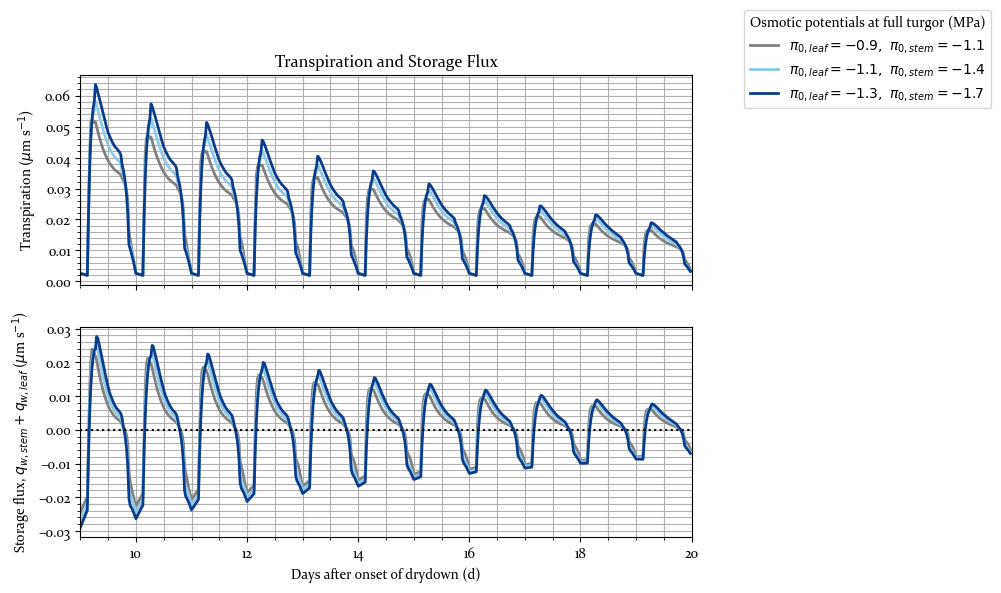

In [13]:
# Plot-window control: show days after burn-in + (start_day_after_burn_in - 1)
start_day_after_burn_in = 10

expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg['name']]["output"]
    candidate_lengths.extend([len(out["ev"]), len(out["qw_stem"]), len(out["qw_leaf"])])
n_plot = min(candidate_lengths)
if n_plot != expected_steps:
    print(f"Warning: plotting {n_plot} steps, expected {expected_steps} from duration/timestep.")

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]  # gray, light blue, dark blue
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
ax_top, ax_bottom = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    ev = np.array(out["ev"])[max_burn_in + plot_start_idx:n_plot]
    qw_stem = np.array(out["qw_stem"])[max_burn_in + plot_start_idx:n_plot]
    qw_leaf = np.array(out["qw_leaf"])[max_burn_in + plot_start_idx:n_plot]
    q_storage_sum = qw_stem + qw_leaf

    ax_top.plot(time_plot, ev, linewidth=2, color=color, label=label)
    ax_bottom.plot(time_plot, q_storage_sum, linewidth=2, color=color, label=label)

# Reference line at zero storage flux
ax_bottom.axhline(0.0, color="black", linestyle=":", linewidth=1.5)

ax_top.set_title("Transpiration and Storage Flux")
ax_top.set_ylabel(r"Transpiration ($\mu$m s$^{-1}$)")
ax_bottom.set_ylabel(r"Storage flux, $q_{w,stem}+q_{w,leaf}$ ($\mu$m s$^{-1}$)")
ax_bottom.set_xlabel("Days after onset of drydown (d)")

xmax = post_burn_duration
xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_top.get_legend_handles_labels()
plt.subplots_adjust(right=0.94)  # Make room on the right for the legend
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.001, 1), loc="upper left")
# fig.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(run_output_dir / "transpiration_storage_flux.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Potentials by Scenario

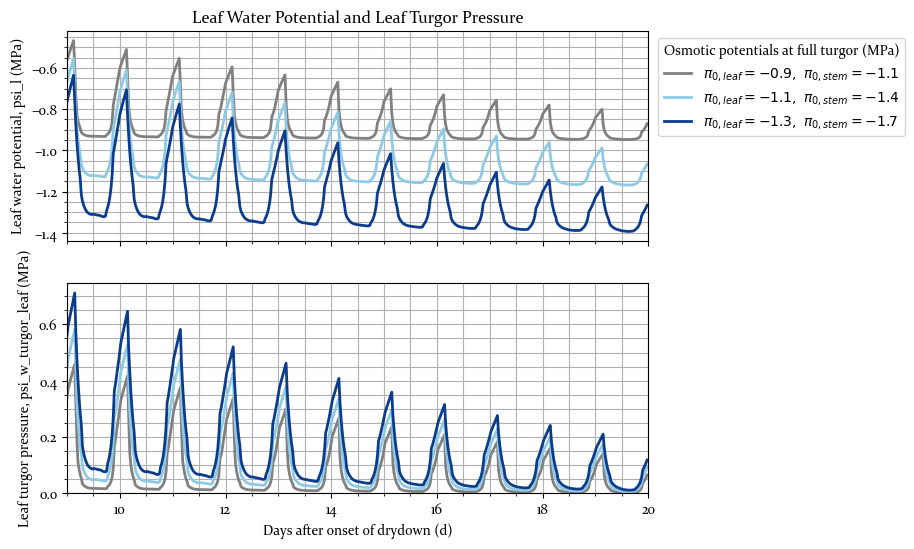

In [14]:
expected_steps = int(duration * 24 * 60 / timestepM)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg['name']]["output"]
    # candidate_lengths.extend([len(out["psi_l"]), len(out["psi_w_stem"]), len(out["psi_w_leaf"]), len(out["psi_w_turgor_leaf"])])
    candidate_lengths.extend([len(out["psi_l"]), len(out["psi_w_turgor_leaf"])])
n_plot = min(candidate_lengths)

# Use the maximum burn-in across scenarios so all series share the same time axis
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

# fig, axes = plt.subplots(4, 1, figsize=(7.5, 6), sharex=True)
fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)

# series_specs = [
#     ("psi_l", "Leaf water potential, psi_l (MPa)"),
#     ("psi_w_stem", "Stem storage potential, psi_w_stem (MPa)"),
#     ("psi_w_leaf", "Leaf storage potential, psi_w_leaf (MPa)"),
#     ("psi_w_turgor_leaf", "Leaf turgor pressure, psi_w_turgor_leaf (MPa)"),
# ]
series_specs = [
    ("psi_l", "Leaf water potential, psi_l (MPa)"),
    ("psi_w_turgor_leaf", "Leaf turgor pressure, psi_w_turgor_leaf (MPa)"),
]

for ax, (key, ylabel) in zip(axes, series_specs):
    for cfg in scenario_configs:
        name = cfg["name"]
        label = results_by_scenario[name]["label"]
        y = np.array(results_by_scenario[name]["output"][key])[max_burn_in + plot_start_idx:n_plot]
        ax.plot(time_plot, y, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(ylabel)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

# Keep turgor axis non-negative for readability
axes[1].set_ylim(bottom=0)

# axes[0].set_title("Potential Comparison Across Sensitivity Scenarios")
axes[0].set_title("Leaf Water Potential and Leaf Turgor Pressure")
axes[-1].set_xlabel("Days after onset of drydown (d)")
axes[-1].set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
axes[0].legend(title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
# plt.tight_layout()
fig.savefig(run_output_dir / "potentials_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Soil Moisture Flux by Scenario


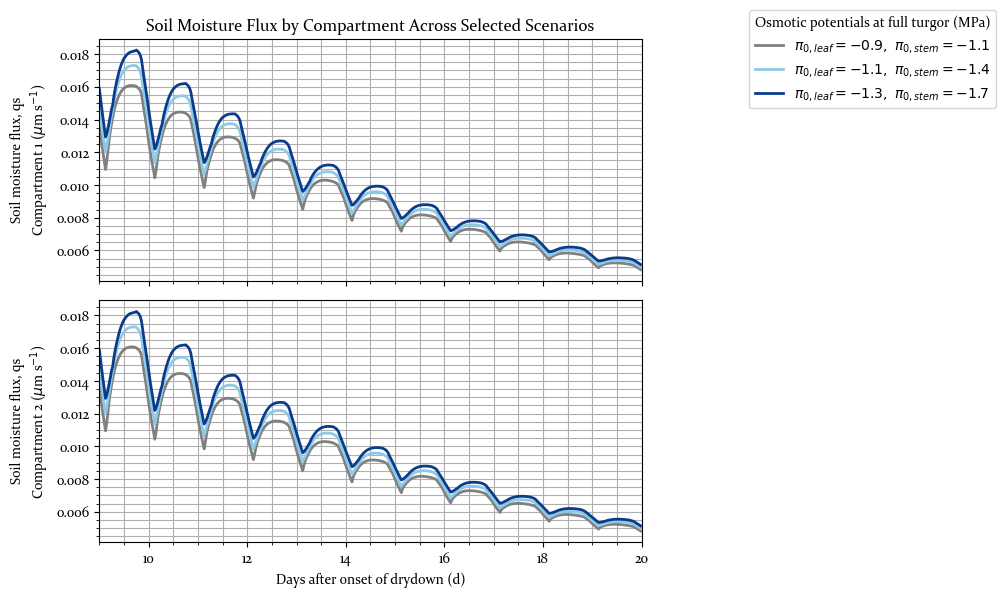

In [15]:
# Select which scenarios to plot (default = all)
scenarios_to_plot = [cfg["name"] for cfg in scenario_configs]
# To restrict, replace the line above with e.g.:
#   scenarios_to_plot = ["R1", "R3"]

candidate_lengths = []
for name in scenarios_to_plot:
    out = results_by_scenario[name]["output"]
    qs = out["qs"]
    for comp_series in qs:
        candidate_lengths.append(len(comp_series))
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

# One subplot per soil compartment
n_comps = len(results_by_scenario[scenarios_to_plot[0]]["output"]["qs"])
fig, axes = plt.subplots(n_comps, 1, figsize=(7.5, 6), sharex=True)
if n_comps == 1:
    axes = [axes]

scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    name: scenario_palette[i % len(scenario_palette)]
    for i, name in enumerate(scenarios_to_plot)
}

for comp_idx, ax in enumerate(axes):
    for name in scenarios_to_plot:
        label = results_by_scenario[name]["label"]
        qs_comp = np.array(results_by_scenario[name]["output"]["qs"][comp_idx])[max_burn_in + plot_start_idx:n_plot]
        ax.plot(time_plot, qs_comp, linewidth=2, color=scenario_colors[name], label=label)
    ax.set_ylabel(f"Soil moisture flux, qs\nCompartment {comp_idx + 1} ($\\mu$m s$^{{-1}}$)")
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_title("Soil Moisture Flux by Compartment Across Selected Scenarios")
axes[-1].set_xlabel("Days after onset of drydown (d)")
axes[-1].set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(run_output_dir / "soil_moisture_flux.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stem and Leaf Water Content by Scenario

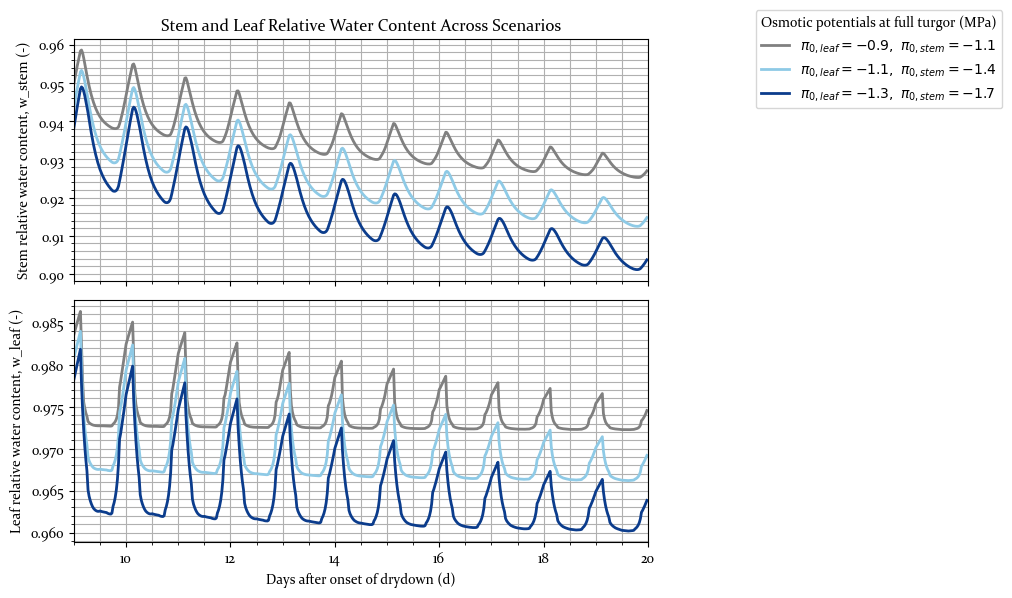

In [16]:
# Plot stem and leaf relative water content for all scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.extend([len(out["w_stem"]), len(out["w_leaf"])])
n_plot = min(candidate_lengths)

max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]
scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
ax_stem, ax_leaf = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    w_stem = np.array(out["w_stem"])[max_burn_in + plot_start_idx:n_plot]
    w_leaf = np.array(out["w_leaf"])[max_burn_in + plot_start_idx:n_plot]

    ax_stem.plot(time_plot, w_stem, linewidth=2, color=color, label=label)
    ax_leaf.plot(time_plot, w_leaf, linewidth=2, color=color, label=label)

ax_stem.set_title("Stem and Leaf Relative Water Content Across Scenarios")
ax_stem.set_ylabel("Stem relative water content, w_stem (-)")
ax_leaf.set_ylabel("Leaf relative water content, w_leaf (-)")
ax_leaf.set_xlabel("Days after onset of drydown (d)")

xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_stem.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(run_output_dir / "stem_leaf_water_content.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot: Stomatal Conductance by Scenario

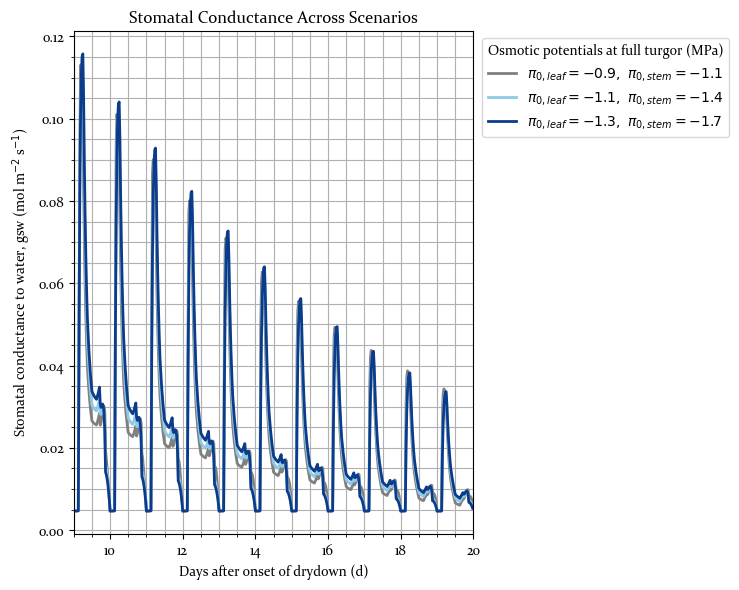

In [17]:
# Plot stomatal conductance (gsw) for all scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.append(len(out["gsw"]))

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]
scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    gsw = np.array(out["gsw"])[max_burn_in + plot_start_idx:n_plot]
    ax.plot(time_plot, gsw, linewidth=2, color=scenario_colors[name], label=label)

ax.set_title("Stomatal Conductance Across Scenarios")
ax.set_xlabel("Days after onset of drydown (d)")
ax.set_ylabel("Stomatal conductance to water, gsw (mol m$^{-2}$ s$^{-1}$)")
ax.set_xlim(time_plot[0] if len(time_plot) else plot_start_day, post_burn_duration)
ax.minorticks_on()
ax.grid(visible=True, which="both", axis="both")
ax.legend(title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
plt.tight_layout()
fig.savefig(run_output_dir / "stomatal_conductance.png", dpi=300, bbox_inches="tight")
plt.show()

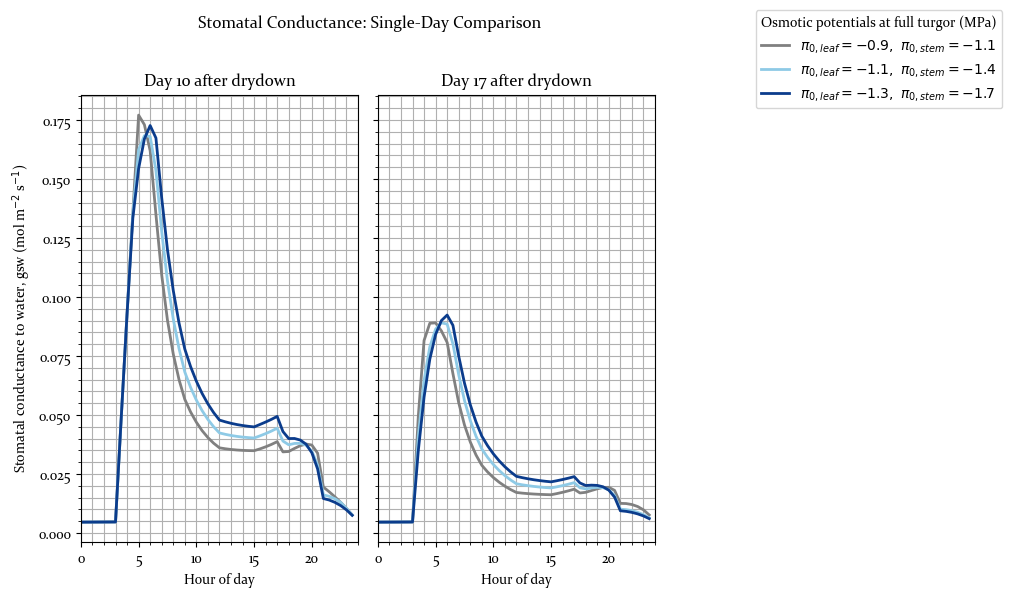

In [70]:
# Plot stomatal conductance for two single-day windows after drydown
# Left panel: day 10 after drydown; Right panel: day 17 after drydown
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.append(len(out["gsw"]))

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

# Interpret "day N after drydown" as the Nth day window: [N-1, N)
comparison_days = [10, 17]
fig, axes = plt.subplots(1, 2, figsize=(7.5, 6), sharey=True)

for ax, day_after_drydown in zip(axes, comparison_days):
    window_start_day = max(float(day_after_drydown) - 1.0, 0.0)
    day_mask = (post_burn_days >= window_start_day) & (post_burn_days < window_start_day + 1.0)
    day_idx = np.where(day_mask)[0]

    if len(day_idx) == 0:
        ax.text(0.5, 0.5, f"No data for day {int(day_after_drydown)}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Day {int(day_after_drydown)} after drydown")
        ax.set_xlabel("Hour of day")
        ax.grid(visible=True, which="both", axis="both")
        continue

    hour_of_day = (post_burn_days[day_idx] - window_start_day) * 24.0

    for cfg in scenario_configs:
        name = cfg["name"]
        label = results_by_scenario[name]["label"]
        out = results_by_scenario[name]["output"]
        gsw_post_burn = np.array(out["gsw"])[max_burn_in:n_plot]
        gsw_day = gsw_post_burn[day_idx]
        ax.plot(hour_of_day, gsw_day, linewidth=2, color=scenario_colors[name], label=label)

    ax.set_title(f"Day {int(day_after_drydown)} after drydown")
    ax.set_xlabel("Hour of day")
    ax.set_xlim(0, 24)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

axes[0].set_ylabel("Stomatal conductance to water, gsw (mol m$^{-2}$ s$^{-1}$)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
fig.suptitle("Stomatal Conductance: Single-Day Comparison")
fig.tight_layout(rect=[0, 0, 0.90, 0.96])
fig.savefig(run_output_dir / "stomatal_conductance_day10_day17.png", dpi=300, bbox_inches="tight")
plt.show()

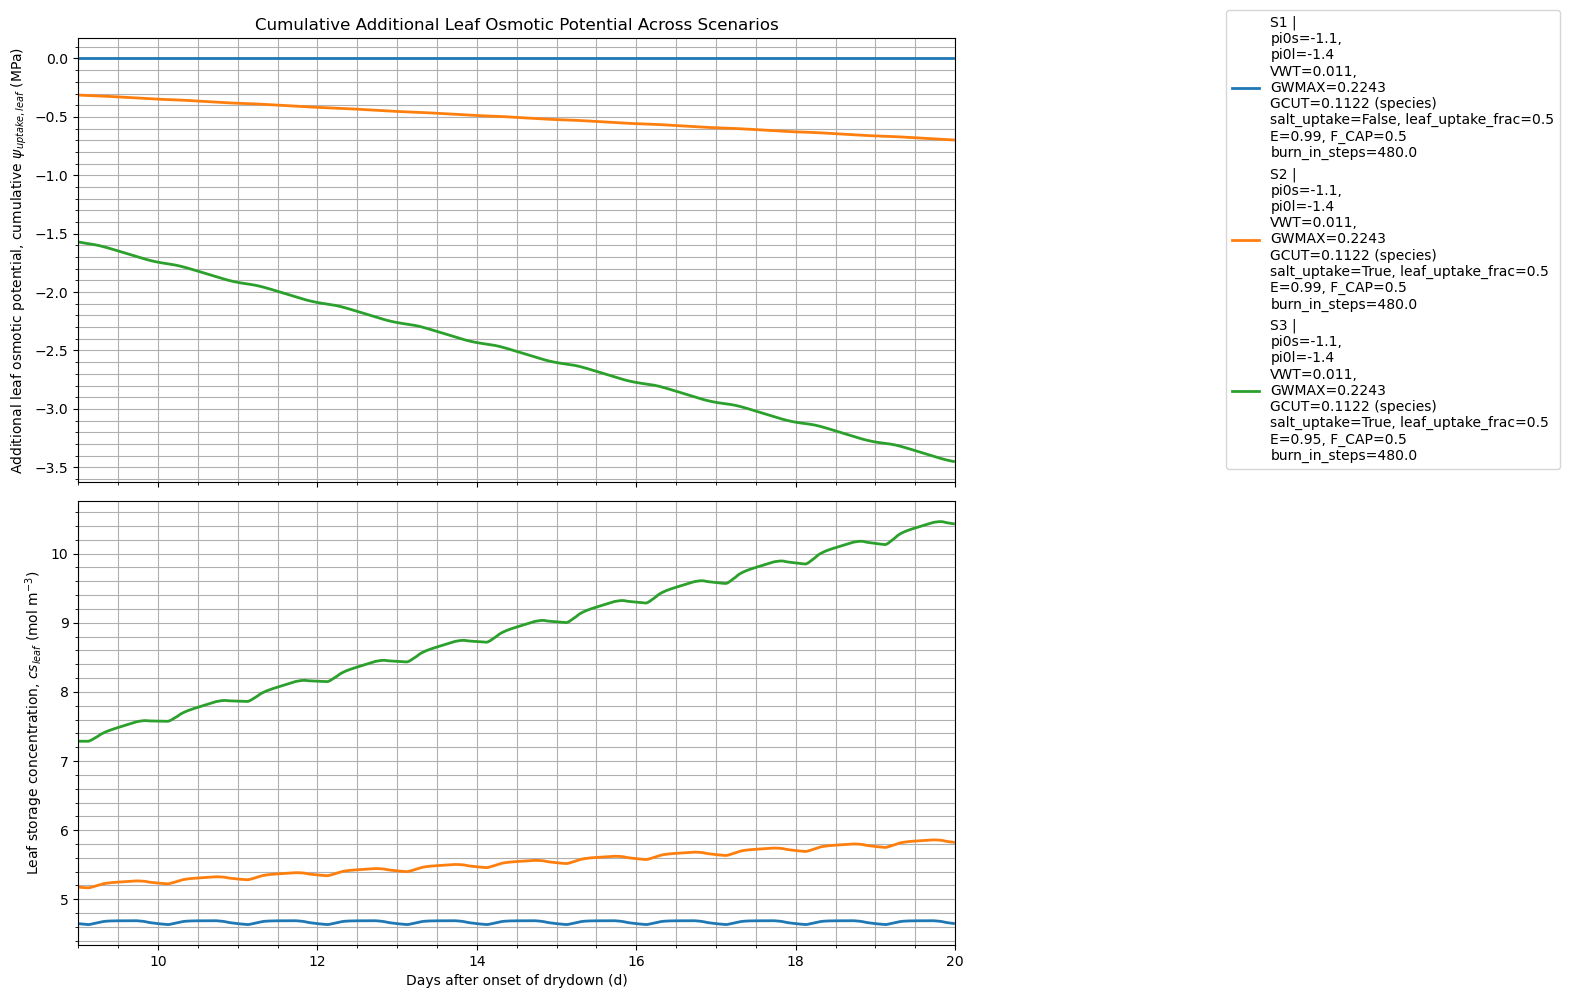

In [ ]:
# Plot cumulative additional leaf osmotic potential and cs_leaf across scenarios (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    psi_leaf_series = out.get("psi_uptake_leaf_cum", out.get("psi_uptake_leaf", []))
    cs_leaf_series = out.get("c_leaf", [])
    candidate_lengths.extend([len(psi_leaf_series), len(cs_leaf_series)])

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]

scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
ax_top, ax_bottom = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]

    psi_uptake_leaf_cum = np.array(out.get("psi_uptake_leaf_cum", out["psi_uptake_leaf"]))[max_burn_in + plot_start_idx:n_plot]
    cs_leaf = np.array(out["c_leaf"])[max_burn_in + plot_start_idx:n_plot]

    ax_top.plot(
        time_plot,
        psi_uptake_leaf_cum,
        linewidth=2,
        color=scenario_colors[name],
        label=label,
    )
    ax_bottom.plot(
        time_plot,
        cs_leaf,
        linewidth=2,
        color=scenario_colors[name],
        label=label,
    )

ax_top.set_title("Cumulative Additional Leaf Osmotic Potential Across Scenarios")
ax_top.set_ylabel(r"Additional leaf osmotic potential, cumulative $\psi_{uptake,leaf}$ (MPa)")
ax_bottom.set_ylabel(r"Leaf storage concentration, $cs_{leaf}$ (mol m$^{-3}$)")
ax_bottom.set_xlabel("Days after onset of drydown (d)")

xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_top.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(run_output_dir / "leaf_osmotic_potential_and_cs_leaf.png", dpi=300, bbox_inches="tight")
plt.show()


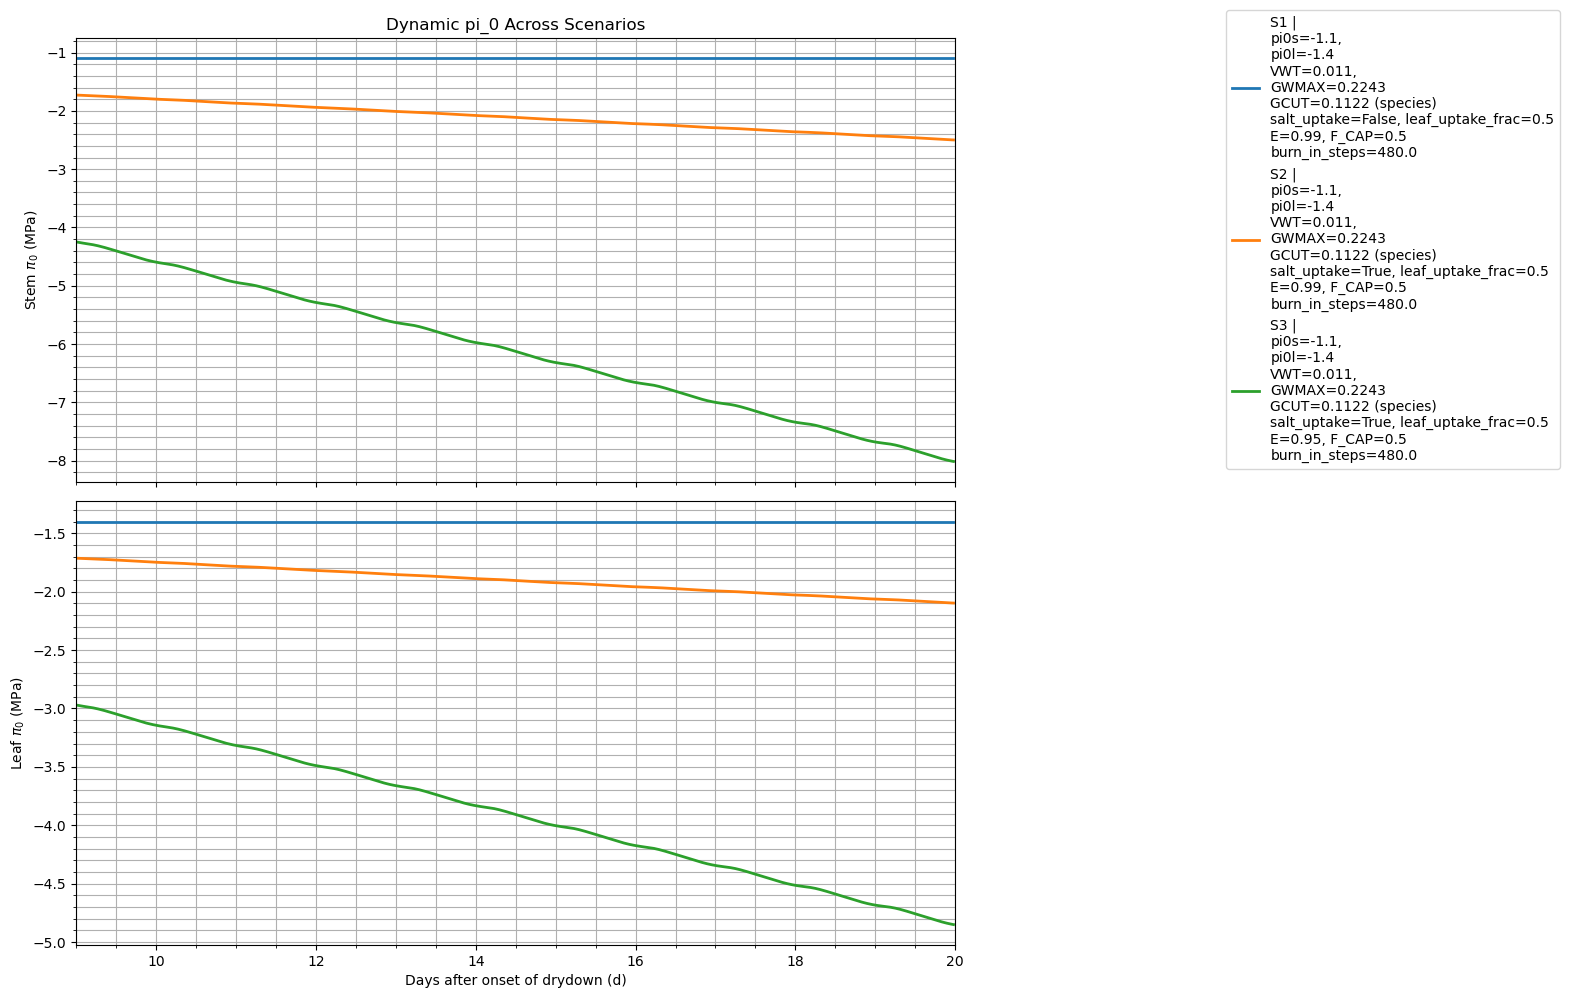

In [ ]:
# Plot pi_0 timeseries for stem and leaf (post-burn-in only)
candidate_lengths = []
for cfg in scenario_configs:
    out = results_by_scenario[cfg["name"]]["output"]
    candidate_lengths.extend([len(out["pi0_stem"]), len(out["pi0_leaf"])])

n_plot = min(candidate_lengths)
max_burn_in = max(results_by_scenario[cfg["name"]]["burn_in_steps"] for cfg in scenario_configs)
post_burn_steps = n_plot - max_burn_in
post_burn_duration = post_burn_steps * dt / 86400.0  # days

post_burn_days = np.arange(post_burn_steps) * dt / 86400.0
plot_start_day = max(float(start_day_after_burn_in) - 1.0, 0.0)
plot_start_idx = int(np.searchsorted(post_burn_days, plot_start_day, side="left"))
time_plot = post_burn_days[plot_start_idx:]
scenario_palette = ["#808080", "#8ecae6", "#0b3c8c"]
scenario_colors = {
    cfg["name"]: scenario_palette[i % len(scenario_palette)]
    for i, cfg in enumerate(scenario_configs)
}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True)
ax_stem_pi0, ax_leaf_pi0 = axes

for cfg in scenario_configs:
    name = cfg["name"]
    label = results_by_scenario[name]["label"]
    out = results_by_scenario[name]["output"]
    color = scenario_colors[name]

    pi0_stem = np.array(out["pi0_stem"])[max_burn_in + plot_start_idx:n_plot]
    pi0_leaf = np.array(out["pi0_leaf"])[max_burn_in + plot_start_idx:n_plot]

    ax_stem_pi0.plot(time_plot, pi0_stem, linewidth=2, color=color, label=label)
    ax_leaf_pi0.plot(time_plot, pi0_leaf, linewidth=2, color=color, label=label)

ax_stem_pi0.set_title("Dynamic pi_0 Across Scenarios")
ax_stem_pi0.set_ylabel(r"Stem $\pi_0$ (MPa)")
ax_leaf_pi0.set_ylabel(r"Leaf $\pi_0$ (MPa)")
ax_leaf_pi0.set_xlabel("Days after onset of drydown (d)")

xmin = time_plot[0] if len(time_plot) else plot_start_day
for ax in axes:
    ax.set_xlim(xmin, post_burn_duration)
    ax.minorticks_on()
    ax.grid(visible=True, which="both", axis="both")

handles, labels = ax_stem_pi0.get_legend_handles_labels()
fig.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.005, 1), loc="upper left")
fig.tight_layout(rect=[0, 0, 0.90, 1])
fig.savefig(run_output_dir / "pi0_stem_leaf_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()